# Архитектура модели PointPillars

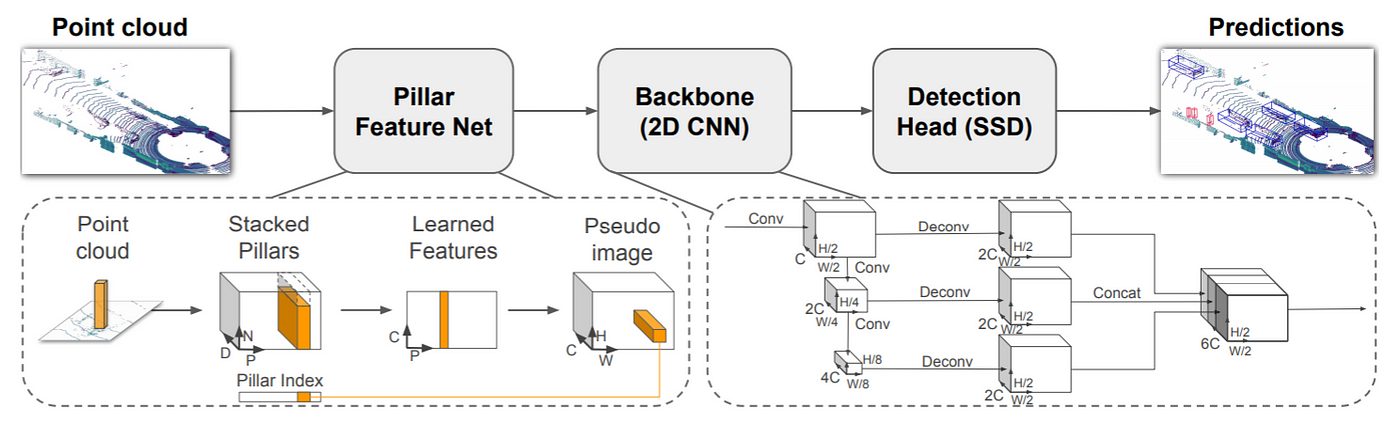

## 1. Введение

Трёхмерная детекция объектов (например, машин и пешеходов) в облаках точек LiDAR имеет ключевое значение для автономного вождения и робототехники. Классические подходы либо проецируют 3D-точки на 2D-плоскости (вид камеры), что обеспечивает высокую скорость, но снижает точность, либо непосредственно работают в 3D с вокселями/точками, достигая лучшей точности ценой большой вычислительной нагрузки.

Метод PointPillars (CVPR 2019) стремится объединить преимущества этих подходов — он обучаемый end-to-end, как 3D-методы, но использует эффективные 2D-свёртки вместо медленных 3D-слоёв. В PointPillars вводится идея столбцов (pillars) — вертикальных столбцов в пространстве, агрегирующих точки по координатам XY и игнорируя деление по высоте Z.

За счёт этого достигается значительный выигрыш в скорости: полный конвейер работает ~62 Гц (≈16 мс на кадр), что в 2–4 раза быстрее предшественников, при сопоставимой точности детекции. Более того, только по данным LiDAR метод превзошёл по качеству даже некоторые решения, объединяющие LiDAR с камерами.

Основные преимущества PointPillars — реальное время работы, высокая точность и отсутствие необходимости ручной настройки параметров под разные датчики.

## 2. Общая архитектура PointPillars

Архитектура PointPillars состоит из трёх этапов:

1. **Pillar Feature Net** — преобразует сырое облако точек в упорядоченное представление (называемое псевдоизображением).
2. **Backbone‑сеть** — 2D‑CNN, извлекающая высокоуровневые признаки из этого псевдоизображения.
3. **Detection Head** — одностадийный детектор, предсказывающий параметры 3D‑bounding‑box объектов.

Исходные необработанные данные — это множество точек $(x, y, z, r)$, где $r$ — интенсивность отражения лазера.

На этапе **Pillar Feature Net** выполняется:
- дискретизация пространства по $X$–$Y$ (вид сверху, BEV);
- группировка точек в столбцы;
- извлечение обучаемых признаков.

Результат — двумерная карта признаков (псевдоизображение) в координатах BEV (Bird’s Eye View, «вид сверху»).

Далее **Backbone** (2D‑свёрточная сеть) обрабатывает эту карту, формируя многомасштабные признаки.

Наконец, **Detection Head** (SSD‑подобная) скользящими свёртками по картам признаков генерирует итоговые предсказания: для каждой области (ячейки) — вероятность наличия объекта каждого класса и параметры ограничивающего 3D‑блока.

**BEV‑представление** (вид сверху) играет ключевую роль. Оно:
- отображает облако точек на регулярную сетку в плоскости земли, что превращает задачу в аналог задачи детекции на изображении сверху;
- сохраняет метрические расстояния и размеры в горизонтальной плоскости;
- позволяет применять эффективные 2D‑CNN для распознавания (объекты — машины, пешеходы — имеют характерные проекции, например, прямоугольные «отпечатки» машин на дороге).

PointPillars использует **разреженность BEV‑пространства**: далеко не каждая ячейка сетки содержит точки. Поэтому вместо плотного 2D‑растрового изображения хранится только список непустых столбцов (pillars) с точками.

Такой подход позволяет значительно сократить вычисления — обрабатываются лишь области с данными, минуя громоздкие 3D‑свёртки.

## 3. Pillar Feature Net (формирование признаков столбцов)

Pillar Feature Net (PFN) преобразует несвязное облако точек в структурированное представление. Этот модуль выполняет три основных шага:


1. **Вокселизация пространства XY**  
   Задаётся дискретная сетка по плоскости $X$–$Y$ с заданным шагом (например, 0.16 м). Каждая ячейка сетки — вертикальный столбец фиксированной площади основания (pillar).  

   Формально для точки с координатами $(x, y)$ индекс столбца вычисляется как:  
   $$
   i = \left\lfloor \frac{x - x_{\min}}{\Delta x} \right\rfloor, \quad
   j = \left\lfloor \frac{y - y_{\min}}{\Delta y} \right\rfloor,
   $$  
   где:  
   - $\Delta x, \Delta y$ — размер ячейки;  
   - $(x_{\min}, y_{\min})$ — минимальные координаты диапазона.  

   Все точки, попадающие в одну ячейку $(i,j)$, относятся к одному pillar.  
   Z‑координата не влияет на принадлежность к столбцу: вся высота сцены проецируется в один bin над данной ячейкой $XY$.  

   Максимальный охватываемый диапазон по $XY$ (например, 0–70 м вперёд и 0–40 м влево/вправо для автономного авто) определяет размеры сетки $(H \times W)$ ячеек.

2. **Группировка точек в pillars и нормализация размера выборки**  
   После дискретизации каждая непустая ячейка даёт один столбец (pillar), содержащий набор точек $\{(x_n, y_n, z_n, r_n)\}_{n=1}^{N_i}$.  

   Количество точек в столбцах неоднородно (от 1 до сотен). Для эффективной обработки тензорными операциями вводятся ограничения:  
   - **Ограничение числа столбцов $P$**: выбирается не более $P$ столбцов на кадр (например, $P = 12\,000$).  
     Если в сцене больше непустых ячеек, случайно выбираются $P$ столбцов; если меньше — заполняются пустышками.  
   - **Ограничение числа точек на столбец $N$**: в каждом столбце берётся до $N$ точек (например, $N = 100$).  
     При избытке точек в pillar производится случайная выборка $N$ точек; если точек меньше $N$, недостающие заполняются нулевыми значениями.  

   В итоге данные каждого кадра представляются фиксированным тензором размера $(D, P, N)$, где $D$ — размер вектор‑признаков одной точки.  
   Для PointPillars обычно $D = 9$, поэтому, например, на KITTI тензор имеет форму $(9, 12\,000, 100)$.

3. **Формирование признаков точек и агрегация по столбцу**  
   Каждая точка имеет атрибуты $(x, y, z, r)$. Эти базовые признаки дополняются геометрическим контекстом:

   - $(x_c, y_c, z_c)$ — координаты точки относительно центра масс всех точек в данном pillar.  
     Вычисляется среднее:  
     $$
     \bar{x}_i = \frac{1}{N_i} \sum_{n=1}^{N_i} x_n, \quad
     \bar{y}_i = \frac{1}{N_i} \sum_{n=1}^{N_i} y_n, \quad
     \bar{z}_i = \frac{1}{N_i} \sum_{n=1}^{N_i} z_n.
     $$  
     Для каждой точки берётся разность:  
     $$
     x_n - \bar{x}_i, \quad y_n - \bar{y}_i, \quad z_n - \bar{z}_i.
     $$  
     Эти признаки описывают локальную форму (например, отличают точки на краю столбца от центральных).

   - $(x_p, y_p)$ — координаты точки относительно дискретного центра столбца.  
     Каждый столбец привязан к центру своей ячейки в глобальной системе координат. Разность  
     $$
     x_n - x_{\text{cell}}, \quad y_n - y_{\text{cell}}
     $$  
     вводит признак положения точки внутри ячейки (помогает учесть расположение столбца в сцене).

   В итоге для каждой точки формируется 9‑мерный вектор признаков:  
   $$
   \mathbf{f}_n = [x_n,\, y_n,\, z_n,\, r_n,\, x_n - \bar{x}_i,\, y_n - \bar{y}_i,\, z_n - \bar{z}_i,\, x_n - x_{\text{cell}},\, y_n - y_{\text{cell}}],
   $$  
   что соответствует $D = 9$ компонентам.

   Этот вектор поступает в небольшую нейросеть на основе PointNet: полносвязный (линейный) слой с BatchNorm и ReLU (эквивалентно 1×1 свёртке, применённой к каждому столбцу и каждой точке).  

   Линейный слой отображает $D$‑мерный вход в $C$‑мерное пространство признаков ($C$ — гиперпараметр, например, $C = 64$):  
   $$
   \mathbf{g}_n = \text{ReLU}(\text{BN}(W \mathbf{f}_n + b)),
   $$  
   где $W$ — матрица весов размером $C \times D$.  

   Результат — набор точечных дескрипторов размерности $C$ для всех $N$ точек каждого столбца (тензор $(C, P, N)$).

4. **Агрегация признаков на уровне столбца**  
   Для каждого столбца по измерению точек $N$ вычисляется свёртка максимума (max pooling):  
   $$
   \mathbf{p}_i = \max_n \mathbf{g}_{i,n},
   $$  
   где $\mathbf{p}_i \in \mathbb{R}^C$ — результирующий признак всего столбца (выделяющий наиболее сильные отклики по каждому из $C$ каналов).

   Этот приём (из PointNet) позволяет не зависеть от числа точек и их порядка: столбец представлен компактным $C$‑мерным дескриптором.  
   После max‑pooling получаем тензор столбцов формы $(C, P)$.

5. **Получение псевдоизображения**  
   Имея признаки всех столбцов $(C, P)$ и их координаты $(i, j)$ в сетке, PFN восстанавливает разреженное изображение вида сверху.

   Инициализируется пустой тензор размера $(C, H, W)$ нулями. Затем для каждого столбца $i$ его вектор $\mathbf{p}_i$ вставляется в позицию, соответствующую индексу столбца:  
   $$
   \text{PseudoImage}[:, j_i, i_i] := \mathbf{p}_i,
   $$  
   где $(i_i, j_i)$ — индексы ячейки столбца в сетке.

   Все ячейки без точек остаются нулевыми. Получается псевдоизображение признаков размером $(C, H, W)$.

   Например, в датасете KITTI при дальности ~70×80 м и шаге 0.16 м сетка имеет размер порядка $H \times W \approx 440 \times 500$; при $C = 64$ размер псевдоизображения ~$64 \times 440 \times 500$.

   Это «изображение» весьма разреженное (объекты занимают считанные столбцы), но готово для обработки стандартной 2D‑CNN.
```

## 4. Backbone (2D CNN)

Backbone — это свёрточная нейронная сеть, предназначенная для извлечения высокоуровневых признаков из псевдоизображения (аналогично экстракции признаков из фотографии в обычных детекторах).

В PointPillars используется архитектура, схожая с бэкбоном VoxelNet/SECOND, состоящая из двух частей:
- **Top‑down путь** (последовательность свёрточных блоков) — несколько блоков свёрточных слоёв, последовательно понижающих разрешение карты и увеличивающих глубину признаков.
- **Upsampling путь** (обратная свёртка и слияние) — восстановление разрешения посредством транспонированных свёрток (deconvolution) и конкатенация признаков разных масштабов.


### Top‑down блоки


Исходное псевдоизображение размера $(C, H, W)$ поступает в первый блок свёрток. Блок определяется тремя параметрами $(S, L, F)$:
- $S$ — совокупный коэффициент downsampling (stride) данного блока относительно исходного разрешения;
- $L$ — число свёрточных слоёв $3 \times 3$ в блоке;
- $F$ — число выходных фильтров (каналов) каждого свёрточного слоя.


Особенности работы блока:
- В первом блоке первая свёртка выполняется с шагом $>1$ (например, `stride = 2`), чтобы перейти к масштабу $H/2 \times W/2$.
- Последующие свёртки блока имеют `stride = 1` (обогащают представление без изменения размера).
- Каждая свёртка сопровождается BatchNorm и ReLU‑активацией.


Пример работы блоков:
1. Первый блок уменьшает размер карты до $(F_1, H/2, W/2)$.
2. Второй блок понижает разрешение ещё вдвое (относительно входа блока, итоговый stride = 4 к оригиналу), выводя карту $(F_2, H/4, W/4)$.
3. Обычно используют 3 свёрточных блока, получая пирамиду разрешений: $1/2$, $1/4$ и $1/8$ от исходного BEV‑разрешения.

**Пример размеров карт** (при $H \times W \approx 448 \times 512$):
- $(C_1, 224 \times 256)$ — после первого блока;
- $(C_2, 112 \times 128)$ — после второго;
- $(C_3, 56 \times 64)$ — после третьего.


### Математическое описание свёрток


Пусть:
- $X$ — входной тензор признаков размера $(C_{\text{in}}, H_{\text{in}}, W_{\text{in}})$;
- $Y$ — выходной тензор $(C_{\text{out}}, H_{\text{out}}, W_{\text{out}})$ после свёртки ядром $K \times K$ с шагом $s$ и паддингом $p$.

Для каждого выходного канала $c_{\text{out}}$ и координаты $(i, j)$ выполняется:
$$
Y_{c_{\text{out}},\, i,\, j} = \sum_{c=1}^{C_{\text{in}}} \sum_{u=0}^{K-1} \sum_{v=0}^{K-1} W^{(c_{\text{out}},\, c)}_{u,v} \cdot X_{c,\, i \cdot s + u - p,\, j \cdot s + v - p} + b_{c_{\text{out}}},
$$
где:
- $W_{u,v}$ — фильтр (ядро свёртки) размера $K \times K$;
- $b$ — смещение.

Размер выходной карты:
$$
H_{\text{out}} = \left\lfloor \frac{H_{\text{in}} - K + 2p}{s} \right\rfloor + 1, \\
W_{\text{out}} = \left\lfloor \frac{W_{\text{in}} - K + 2p}{s} \right\rfloor + 1.
$$

**Пример**: при $K=3$, $p=1$ и $s=2$ выходные размеры примерно вдвое меньше входных.

В Backbone PointPillars:
- Первые свёртки блоков имеют $s=2$ (downsample);
- Остальные — $s=1$ (без дальнейшего downsample внутри блока).

### Upsampling и слияние

После top‑down блоков получаем набор карт признаков разного разрешения. Цель этапа — объединить:
- семантику крупного масштаба (глубокие признаки с низким разрешением, хорошо распознающие класс объекта);
- детали высокого разрешения (мелкие признаки, содержащие локализацию).


Этап аналогичен FPN/UNet:
1. Каждый пониженный признак масштабируется вверх до общего разрешения с помощью транспонированной свёртки (deconv).
2. Выбирается промежуточное разрешение (в PointPillars — $\frac{H}{2} \times \frac{W}{2}$).

**Примеры масштабирования**:
- Карта с масштабом $1/2$ остаётся без изменений (или проходит простую свёртку для сокращения каналов).
- Карту с масштабом $1/4$ увеличивают в 2 раза (stride = 2 транспонированной свёрткой) до $1/2$.
- Карту $1/8$ увеличивают в 4 раза до $1/2$.


После upsampling (с BN+ReLU) все карты имеют размер $(\cdot,\, H/2,\, W/2)$. Они конкатенируются по каналам в одну итоговую карту признаков.


**Пример объединения**:
- Три карты имели $C_1$, $C_2$, $C_3$ каналов.
- Объединённый выход: $C_{\text{out}} = C_1 + C_2 + C_3$ каналов (в оригинале — около $6C$ каналов суммарно).

Итоговая карта признаков: $(6C, H/2, W/2)$. Она содержит информацию от разных масштабов и подаётся на детектор.


**Примечание**: выбор разрешения $H/2$ вместо исходного $H$ снижает нагрузку на следующий этап, практически не ухудшая качество (ускорение инференса).

## 5. Detection Head (SSD‑детектор)

В PointPillars используется одностадийная схема детекции (single‑stage). Detection Head по структуре аналогичен Single Shot Detector (SSD) для 2D‑изображений, но приспособлен под BEV‑карты и 3D‑боксы.

### Принцип работы

Детектор скользит по выходной карте признаков Backbone и в каждой ячейке (пространственной позиции) генерирует несколько предсказаний объектов относительно **якорных (anchor) рамок**.

**Якорь** — это заранее заданный прямоугольный 3D‑бокс определённого размера и ориентации, расположенный в центре данной ячейки.

В результате работы Head получается множество предсказанных боксов, которые затем:
- фильтруются с помощью NMS (Non‑Maximum Suppression);
- выдаются как финальные детекции.

### Архитектура Detection Head

Модуль реализован парой свёрточных слоёв:
1. **Классификатор** (например, свёрточный слой $1 \times 1$):  
   - выводит для каждой позиции и каждого якоря оценку принадлежности к классу (или «фон»);  
   - формирует вероятности объекта каждого типа;  
   - даёт $A \times N_{\text{class}}$ каналов (где $A$ — число якорей на ячейку, $N_{\text{class}}$ — число классов).

2. **Регрессор**:  
   - выводит параметры поправки (deltas) к координатам каждого якоря;  
   - предсказывает 7 параметров:  
     - центральное смещение: $(\Delta x, \Delta y, \Delta z)$;  
     - размеры: $(\Delta w, \Delta l, \Delta h)$;  
     - поворот: $\Delta \theta$;  
   - формирует $A \times 7$ каналов.

Слои сканируют всю карту, формируя выходные тензоры с предсказаниями для всех позиций сразу (аналогично SSD/YOLO для изображений).

### Преимущества одностадийного подхода

- Финальные оценки получаются за один прогон сети.
- Отсутствует отдельный этап region proposal (в отличие от двухстадийных R‑CNN).
- Ускорение работы.

Для поддержания высокого качества используются:
- продуманная схема якорей;
- специальная функция потерь.


### Кодирование 3D‑бокса

Каждый предсказанный бокс кодируется семью параметрами:  
$$
(x, y, z, w, l, h, \theta),
$$  
где:
- $(x, y, z)$ — координаты центра объекта;
- $w$ — ширина;
- $l$ — длина;
- $h$ — высота;
- $\theta$ — ориентация (азимут, угол yaw) объекта.

### Предсказание отклонений от якоря

Сеть предсказывает не абсолютные значения, а отклонения относительно параметров якоря.

Пусть для данной сеточной позиции задан якорь с параметрами:  
$$
(x_a, y_a, z_a, w_a, l_a, h_a, \theta_a).
$$

Сеть выводит значения:  
$$
(\Delta x, \Delta y, \Delta z, \Delta w, \Delta l, \Delta h, \Delta \theta),
$$  
из которых восстанавливаются финальные координаты бокса:

$$
\begin{aligned}
x_{\text{pred}} &= x_a + \Delta x \cdot w_a, \\
y_{\text{pred}} &= y_a + \Delta y \cdot l_a, \\
z_{\text{pred}} &= z_a + \Delta z \cdot h_a, \\
w_{\text{pred}} &= w_a \exp(\Delta w), \\
l_{\text{pred}} &= l_a \exp(\Delta l), \\
h_{\text{pred}} &= h_a \exp(\Delta h), \\
\theta_{\text{pred}} &= \theta_a + \Delta \theta.
\end{aligned}
$$

**Особенности кодирования**:
- Размеры предсказываются в логарифмическом масштабе (нормализация отклонений).
- Угол кодируется через $\sin(\theta_{\text{gt}} - \theta_a)$ (сглаживание цикличности угла).
- Вводится дополнительный бинарный классификатор ориентации (0° vs 180°), чтобы разрешить неопределённость синуса (не различает углы, отличающиеся на $\pi$).

В комбинации эти два выхода позволяют полноценно восстановить угол ориентации объекта.
```

## 6. Якоря (Anchors)

Якоря — центральный элемент одностадийной детекции. В PointPillars используется подход якорей из VoxelNet/SECOND: всё пространство BEV покрывается сеткой боксов‑кандидатов фиксированных размеров.

### Определение якорей

Для каждого класса объектов задаётся несколько типовых 3D‑боксов (размеров и ориентировок), служащих «шаблонами» для поиска объектов.

**Примеры якорей:**
- Для класса «автомобиль»:  
  - размеры ~$1{,}6 \times 3{,}9 \times 1{,}5$ м (ширина × длина × высота);  
  - ориентации: 0° (вдоль оси $X$) и 90° (вдоль $Y$) — для учёта машин, стоящих боком.
- Для пешеходов: ~$0{,}6 \times 0{,}6 \times 1{,}7$ м.
- Для велосипедов: средний размер.

**Расположение якорей:**
- Центры якорей — в узлах сетки BEV.
- По вертикали центр обычно фиксируется на уровне дороги ($z=0$) или на половине высоты объекта.
- Каждая ячейка $XY$ может иметь $A$ разных якорей (по размерам/ориентациям).

**Пример расчёта числа якорей:**  
Если для 3 классов определено по 2 типа якорей (ориентации 0°/90°), то $A = 3 \times 2 = 6$ якорей на позицию.

### Генерация и сопоставление (matching)

Якоря служат опорными точками для предсказаний. В процессе тренировки им назначается соответствие с реальными объектами (ground truth).

**Схема matching:**
1. Вычисляется IoU (перекрытие) каждого якорного бокса с каждым реальным боксом.
2. Якорь с наибольшим IoU для каждого объекта и все якоря с IoU > 0,6 помечаются как **положительные** (объект присутствует).
3. Якоря с IoU < 0,45 помечаются как **отрицательные** (объекта нет) — на них сеть учится выдавать «фон».

**Особенности PointPillars:**
- Используется IoU по проекции BEV (по $XY$, axis‑aligned): игнорируются различия по высоте и повороту.
- Высота и угол объекта не учитываются при matching — они предсказываются отдельно регрессором.
- Для исключения дублирования: если у объекта несколько якорей выше порога IoU, берётся один best anchor, остальные игнорируются.


### Функция потерь

Общая функция потерь:  
$$
L_{\text{total}} = L_{\text{cls}} + \alpha \cdot L_{\text{reg}},
$$  
где:  
- $L_{\text{cls}}$ — потери классификации (фон/класс);  
- $L_{\text{reg}}$ — потери регрессии параметров;  
- $\alpha$ — весовой коэффициент.


**1. Потери классификации ($L_{\text{cls}}$)**  
Применяется focal loss (фокальная cross‑entropy) для каждого якоря:  
$$
FL(p) = -\alpha (1-p)^{\gamma} \log(p),
$$  
где $p$ — предсказанная вероятность положительного примера.  

**Параметры:**  
- $\gamma = 2$ (степень фокусировки);  
- $\alpha$ — балансировочный параметр.  

**Эффект:** повышает вклад редких положительных примеров и понижает вклад многочисленных отрицательных, смягчая дисбаланс.

**2. Потери регрессии ($L_{\text{reg}}$)**  
Для каждого положительного якоря считаются ошибки в предсказанных параметрах $(\Delta x, \Delta y, \dots, \Delta \theta)$ по сравнению с истинными значениями из $GT$-бокса.

Используется сглаженная L1 (Huber) функция:  
$$
L_{\text{reg}} = \text{Smooth-}L1(\hat{\Delta} - \Delta^*).
$$  

**Специальные целевые преобразования параметров:**  
- $x, y, z$: разности делятся на размер якоря;  
- $w, l, h$: логарифмические отношения;  
- $\theta$: sin‑разность ($\sin(\theta_{\text{gt}} - \theta_a)$).  

В итоговый $L_{\text{reg}}$ входят ошибки по всем 7 параметрам, суммированные с весовыми коэффициентами (иногда высоту и угол взвешивают меньше).

**3. Дополнительные потери ориентации**  
Вводится отдельная классификация на 2 класса для уточнения $180^\circ$-симметрии угла.  
- Используется кроссэнтропия (двуклассовый softmax).  
- Добавляется к общим потерям с небольшим весом.


### Инференс

После тренировки:
1. Из всех предсказанных боксов отбираются те, у которых высокая уверенность.
2. Выполняется Non‑Maximum Suppression (NMS) на плоскости BEV для устранения дублирующих предсказаний.

**Особенность PointPillars:**  
Используется быстрая axis‑aligned NMS (по проекциям без учёта поворота). Это может оставить пару близких наклонённых рамок, но на практике работает хорошо и ускоряет обработку.

### Краткое описание этапов обработки данных

**1. Формирование признаков точек**

* **Вход:**  
  - Облако точек с атрибутами $(x, y, z, r)$  
  - Количество точек в столбце $N_i$

* **Процесс:**  
  1. Вычисление центра масс для каждого столбца  
  2. Добавление относительных координат  
  3. Формирование 9-мерного вектора признаков для каждой точки

* **Выход:**  
  - 9-мерный вектор признаков для каждой точки:  
    $\mathbf{f}_n = [x_n, y_n, z_n, r_n, x_n - \bar{x}_i, y_n - \bar{y}_i, z_n - \bar{z}_i, x_n - x_{\text{cell}}, y_n - y_{\text{cell}}]$  
  - Тензор признаков точек: $(D=9, P, N)$



**2. Нейросеть PointNet-энкодер**

* **Вход:**  
  - Тензор признаков точек $(9, P, N)$

* **Процесс:**  
  - Линейный слой с BatchNorm и ReLU  
  - Отображение $D \rightarrow C$

* **Выход:**  
  - Точечные дескрипторы:  
    $\mathbf{g}_n = \text{ReLU}(\text{BN}(W \mathbf{f}_n + b))$  
  - Тензор $(C, P, N)$, где $C$ - размерность признаков (например, 64)



**3. Агрегация по столбцу**

* **Вход:**  
  - Тензор точечных признаков $(C, P, N)$

* **Процесс:**  
  - Max pooling по измерению точек $N$

* **Выход:**  
  - Столбцовые признаки:  
    $\mathbf{p}_i = \max_n \mathbf{g}_{i,n}$  
  - Тензор признаков столбцов: $(C, P)$


**4. Формирование псевдоизображения**

* **Вход:**  
  - Признаки столбцов: $(C, P)$  
  - Координаты столбцов $(i, j)$

* **Процесс:**  
  - Размещение признаков в соответствующие позиции сетки

* **Выход:**  
  - Псевдоизображение признаков:  
    $\text{PseudoImage}[:, j_i, i_i] := \mathbf{p}_i$  
  - Тензор размерности $(C, H, W)$, где:  
    * $C$ - каналы признаков  
    * $H, W$ - высота и ширина сетки BEV

**5. Обработка псевдоизображения с помощью CNN**

* **Вход:**  
  - Псевдоизображение признаков: $(C, H, W)$

* **Процесс:**  
  - Применение серии 2D свёрточных слоёв  
  - Извлечение признаков из псевдоизображения  
  - Увеличение семантической информации

* **Выход:**  
  - Увеличенный тензор признаков: $(C', H', W')$, где:  
    * $C'$ - новая размерность каналов  
    * $H', W'$ - изменённые размеры после свёрток



**6. Детектирующий заголовок (Detection Head)**

* **Вход:**  
  - Признаки от CNN: $(C', H', W')$

* **Процесс:**  
  - Классификация объектов  
  - Регрессия параметров bounding box  
  - Оценка ориентации и размеров

* **Выход:**  
  - Карта классификаций: $(K, H', W')$, где $K$ - количество классов  
  - Параметры bounding box: $(5, H', W')$ (x, y, z, w, l, h, θ)  
  - Итоговый тензор предсказаний

## 7. Особенности и преимущества PointPillars

PointPillars быстро стал популярным благодаря сочетанию простоты и эффективности. Ключевые преимущества архитектуры:


### 1. Компактность и скорость реального времени
- Модель полностью избавилась от 3D‑слоёв, используя:
  - легковесный PointNet‑энкодер;
  - 2D‑CNN.
- Количество параметров и операций существенно меньше, чем у предшественников (VoxelNet и др.).
- **Скорость инференса**: 50–60 FPS на GPU без ощутимой потери качества.
- На наборе KITTI: ~16 мс на кадр (62 Гц) при точности, сопоставимой с лучшими более медленными моделями.
- При снижении разрешения столбцов скорость можно повысить до **105 FPS**.
- Запас производительности критичен для реальных применений:
  - лидар обычно даёт 10–20 кадров/с;
  - нужен резерв для сложных сцен и слабых бортовых GPU.


### 2. Оптимизация с TensorRT и развёртывание
- Все расчёты отлично встраиваются в GPU‑вычисления.
- Перенос операций (энкодер столбцов, свёртки backbone, head) в NVIDIA TensorRT дал **~45 % ускорение** по сравнению с PyTorch.
- Совместимость с TensorRT обеспечивает:
  - лёгкое развёртывание на встраиваемых устройствах (автопилоты, робототехнические системы);
  - максимальную оптимизацию вычислений.
- Архитектура рассчитана на удобство production‑внедрения:
  - нет сложных слоёв;
  - целочисленная дискретизация входа;
  - упрощённое квантование и тюнинг.

### 3. Высокая точность при простоте
- На момент публикации (2019) PointPillars достиг **state‑of‑the‑art** качества на KITTI benchmark по 3D‑детекции машин среди методов только на лидаре.
- Практически сравнялся по AP с более тяжёлыми фьюжен‑методами, обогнав другие LiDAR‑сети.
- Причина успеха: Pillar Feature Net учится оптимальным признакам из данных, а не полагается на жёстко заданные проекции или фичи.
- Модель адаптивно использует всю информацию облака точек, что было сложно в ранних методах с фиксированными проекциями.


### 4. Гибкость и простота настройки
- В отличие от вокселизационных подходов, PointPillars:
  - не требует ручного выбора шага по высоте $Z$ (весь вертикальный диапазон учитывается в столбце);
  - не имеет параметра «толщины слоя» (сетка задаётся только по $XY$).
- Модель не чувствительна к различиям между лидарами:
  - применима к другому сенсору (с другой плотностью точек) с минимальными изменениями;
  - требуется лишь задать подходящий диапазон и шаг по $XY$.
- Не нужна ручная подгонка под разные конфигурации датчиков — упрощён перенос между проектами.


### 5. Поддержка сообществом и библиотеки
- Благодаря открытой публикации и балансу «скорость/точность» PointPillars реализован во многих open‑source фреймворках:
  - OpenPCDet;
  - MMDetection3D;
  - TensorFlow Graphics и др.
- Часто используется как базовый бэкбон для исследований.
- В открытых репозиториях обычно заложены параметры:
  - $D = 9$;
  - $P = 12\,000$;
  - $N = 100$.
- NVIDIA включила PointPillars в свой набор примеров (адаптировав под TensorRT, см. NVIDIA TAO Toolkit).
- Модель стала **де‑факто стандартом** для задач детекции по облакам точек, где критична производительность.

## 8. Ограничения архитектуры

Несмотря на успех, PointPillars имеет ряд ограничений, особенно заметных в свете появившихся после 2019 года методов:


- **Потеря 3D‑деталей из‑за проекции в BEV.** Главное упрощение Pillars — проекция всего столбца в одну ячейку — приводит к тому, что точная структура по высоте теряется. Признаки столбца стараются закодировать эту структуру, но глубокая нейросеть уже не видит распределения точек по высоте явно. Это может затруднить различие, например, двух объектов, находящихся один над другим (мост и машина под ним) или предметов, свисающих сверху. В общем, псевдоизображение не хранит истинную 3D‑геометрию сцены, что заложило потолок точности PointPillars по сравнению с более новыми 3D‑детекторами, которые сохраняют больше объёмной информации.

- **Сложности с детекцией дальних и частично видимых объектов.** Как показала практика, PointPillars хуже распознаёт удалённые и особенно частично наблюдаемые (окклюдированные) цели. Причина в локальности признаков: обучение столбцов происходит в основном на основе точек внутри одного grid‑bin. Глобальный контекст сцены не используется явно — нет механизма учитывания удалённых зависимостей (например, для дальних объектов могло бы помочь видеть окружающую дорогу, соседние объекты и т. п.). В результате сеть может пропускать пешеходов далеко впереди или объекты, частично скрытые за другими, поскольку в их столбцах слишком мало информации. Решение этой проблемы в более поздних работах — введение модулей внимания и глобальных связей, либо многоэтапное уточнение с привлечением более крупного контекста.


- **Отсутствие современных модулей: внимание (attention), мультивидовые представления.** Архитектура PointPillars предшествует появлению трансформеров и attention‑механизмов в 3D‑детекции. В ней нет средств самовнимания, которые могли бы, например, взвешивать важность разных столбцов или точек и объединять информацию между дальними областями сцены. Новейшие работы (CenterPoint, Voxel R‑CNN и др.) показывают, что использование attention повышает точность, особенно для сложных случаев.


  Кроме того, PointPillars — одноракурсная: она использует только вид сверху, тогда как некоторые современные решения объединяют несколько представлений (например, BEV + фронтальная проекция, или LiDAR + камеры). Отсутствие мультивидового фьюжна означает, что Pillars может пропускать объекты, трудно различимые в одной проекции. Например, длинные объекты или вертикальные структуры могут быть неочевидны в BEV.
  
  Также она не использует данные камеры, тогда как мультисенсорные подходы сейчас улучшили результаты.
  
  Эти упрощения были компромиссом ради скорости, и на момент 2019 г. это оправдано, но по состоянию на 2025 г. модель уступает более комплексным архитектурам по абсолютной точности.



**Вывод:** PointPillars стала важной вехой в 3D‑обнаружении объектов, предложив удачный компромисс между качеством и скоростью за счёт новаторской идеи pillar‑энкодера. Она доказала, что можно обрабатывать облака точек почти так же быстро, как изображения, без существенной потери информации.


Метод до сих пор служит базой для улучшений — например, введения attention‑модулей, двухэтапных детекторов на основе pillar‑карт, или гибридных подходов, преодолевающих перечисленные ограничения. Тем не менее, даже в изначальном виде PointPillars остаётся одним из самых практичных решений для реальных систем, требующих быстрого и достаточно точного обнаружения 3D‑объектов.


# Конфигурация сети

## 1. Структура конфигурации

Конфигурационный файл состоит из трёх основных логических блоков:

1. **dataset** - настройки данных, путей и размера эпох.
2. **model** - архитектура PointPillars: вокселизация, энкодер, backbone, neck и detection head.
3. **pipeline** - процесс обучения: оптимизатор, логирование, сохранение чекпойнтов и параметры оценки.

Ниже перечислены все блоки и параметры в академически оформленном виде.

---

## 2. Блок `dataset`

Этот раздел описывает, как загружается датасет и как формируются эпохи обучения.

### 2.1. `name`

```yaml
name: KITTI
```

Выбор класса датасета, который будет использовать Open3D-ML.
Для KITTI оставляется без изменений.
Меняется только при создании собственного датасета.

### 2.2. `dataset_path`

Путь к корневой директории KITTI.

Менять необходимо всегда - должен указывать на локальную структуру данных.

### 2.3. `cache_dir`

Папка для хранения промежуточных кэшей.
Ускоряет повторные запуски.

Изменять имеет смысл, если:

* требуется хранить кэш на быстром SSD;
* вы запускаете несколько экспериментов в одной директории.

### 2.4. `steps_per_epoch_train`

Количество шагов, которое трактуется как одна эпоха обучения.

Используется для:

* балансировки длины эпохи;
* ускоренного логирования;
* стабилизации обучения на маленьких датасетах.

---

## 3. Блок `model`

Здесь содержится описание всей архитектуры PointPillars от вокселизации до detection head.

---

### 3.1. Общие параметры модели

#### 3.1.1. `name`

```yaml
name: PointPillars
```

Тип используемой модели.
Меняется при переходе на другую архитектуру (например, CenterPoint).

#### 3.1.2. `ckpt_path`

Путь к загружаемому чекпойнту.

Используется для:

* возобновления обучения,
* дообучения,
* инференса с заранее обученной модели.

#### 3.1.3. `batcher: ignore`

Настройка внутреннего батчера Open3D-ML.
Для PointPillars рекомендуется оставить неизменным.

---

### 3.2. `point_cloud_range`

```yaml
point_cloud_range: [xmin, ymin, zmin, xmax, ymax, zmax]
```

Область пространства, в которой работает модель.

Пример для KITTI:

```
[0, -39.68, -3, 69.12, 39.68, 1]
```

Этот диапазон определяет:

* какие точки учитываются;
* размеры BEV-сетки;
* позиции anchor-боксов.

**Когда менять:**

* при использовании другого лидара;
* при изменении рабочей зоны (например, только перед автомобилем);
* при создании собственных датасетов.

---

### 3.3. `classes`

Список классов детекции.

Обычно:

```
['Pedestrian', 'Cyclist', 'Car']
```

Изменение требует также модификации:

* блока anchor-боксов (`ranges`, `sizes`),
* логики аугментации (`ObjectSample`),
* метрик (`overlaps`).

---

## 4. Блок `loss`

PointPillars использует комбинацию классификационных и регрессионных потерь.

---

### 4.1. Focal Loss

Параметры:

* `gamma` - подавляет вклад лёгких негативов.
* `alpha` - баланс позитивных и негативных примеров.
* `loss_weight` - вес классификационной части.

**Когда менять:**

* если модель выдаёт много ложных детекций, увеличивают `gamma`;
* если позитивов мало (редкий класс) - увеличивают `alpha`.

---

### 4.2. Smooth L1

Используется для регрессии параметров бокса.

* `beta` регулирует форму функции (между L1 и L2);
* `loss_weight` - важность регрессионной части.

**Когда менять:**

* если координаты боксов «прыгают» или переобучаются.

---

### 4.3. Cross-Entropy Loss

Служит для дополнительных задач, например, предсказания бинарной ориентации.

---

## 5. Блок `voxelize`

Определяет, как облако точек преобразуется в набор pillars.

### 5.1. `max_num_points`

Максимальное количество точек в одном pillar.

Если pillar содержит больше - точки случайно сэмплируются.

**Менять:**

* при больших плотностях точек;
* при ограничениях по памяти.

---

### 5.2. `voxel_size`

Размер pillar в метрах:

```
[vx, vy, vz]
```

Для Pillars:

* vx = vy ≈ 0.16 (разрешение BEV)
* vz покрывает весь диапазон по высоте (обычно равен zmax−zmin)

**Менять:**

* уменьшение vx,v y --> выше качество, медленнее сеть;
* увеличение --> быстрее, хуже детекция мелких объектов;
* изменение vz почти не используется - Pillars всегда 1 bin по Z.

---

### 5.3. `max_voxels`

Максимальное количество pillar в сцене.

Уменьшение - улучшает скорость, но может терять мелкие объекты.

---

## 6. Блок `voxel_encoder`

Модуль Pillar Feature Net.

### 6.1. `in_channels`

Обычно 4 (x, y, z, r).

Увеличивать при добавлении новых признаков.

### 6.2. `feat_channels`

Например: `[64]`
Размерность выходного признака для одного pillar.

**Когда менять:**

* увеличить до 96/128, если нужно больше выразительности;
* уменьшить при ограниченных ресурсах.

---

## 7. Блок `scatter`

### 7.1. `output_shape`

Размер карты BEV после scatter:

```
H = (ymax - ymin) / vy
W = (xmax - xmin) / vx
```

Должен вычисляться строго из `point_cloud_range` и `voxel_size`.

**Менять:**

* всегда после изменения диапазонов или voxel_size.

---

## 8. Блок `backbone`

2D CNN, обрабатывающая BEV-карту как изображение.

### Основные параметры:

* `in_channels`: должно совпадать с выходом `voxel_encoder`
* `out_channels`: количество каналов в блоках backbone
* `layer_nums`: глубина каждого блока
* `layer_strides`: stride первой свёртки в блоке (определяет уменьшение разрешения)

**Менять:**

* уменьшать stride для детекции более мелких объектов;
* увеличивать число каналов для повышения точности;
* уменьшать каналы для низких GPU.

---

## 9. Блок `neck`

FPN-подобная структура для объединения многоуровневых признаков.

### Параметры:

* `in_channels`: из backbone
* `out_channels`: число каналов после преобразования
* `upsample_strides`: во сколько раз увеличивается карта
* `use_conv_for_no_stride`: нужен ли conv при stride=1

**Менять:**

* при изменении backbone (размеров карт и каналов);
* при необходимости более мощного FPN.

---

## 10. Блок `head` - детектор (SSD-подобный)

Это один из ключевых блоков, так как здесь задаются anchor-боксы.

### 10.1. `in_channels`

Сумма `neck.out_channels`.

### 10.2. `feat_channels`

Размерность промежуточных слоёв детектора.

### 10.3. `nms_pre`

Сколько кандидатов оставить до NMS.

### 10.4. `score_thr`

Порог отсечения слабых детекций.

### 10.5. Anchor-параметры

#### 10.5.1. `ranges`

Диапазоны, в которых создаются anchor-боксы для каждого класса.

Важно согласовать с `point_cloud_range`.

#### 10.5.2. `sizes`

Размеры anchor-боксов в виде:

```
[width, length, height]
```

Должны соответствовать медианным размерам объектов класса.

#### 10.5.3. `rotations`

Список yaw-ориентаций anchor-боксов.

Обычно `[0, 1.57]`.

#### 10.5.4. `iou_thr`

IoU пороги для назначения anchor:
Меняются при других объектах или других метриках.

---

## 11. Блок `augment`

Аугментации, специфичные для LiDAR.

#### 11.1. `PointShuffle`

Перемешивание порядка точек.

#### 11.2. `ObjectRangeFilter`

Удаление объектов, которые не попадают в диапазон.

#### 11.3. `ObjectSample`

Сэмплирование объектов из пула GT (database sampling).

Параметры:

* `min_points_dict` - минимальное число точек для валидного объекта
* `sample_dict` - сколько объектов добавлять на сцену

Менять при:

* редких объектах,
* искусственно малом количестве аннотаций.

---

## 12. Блок `pipeline`

Оркестрация обучения.

---

### 12.1. Основные параметры обучения

#### `batch_size`

Размер батча на обучении.

#### `val_batch_size`, `test_batch_size`

8/16/32

#### `save_ckpt_freq`

Частота сохранения чекпойнтов.

#### `max_epoch`

Количество эпох.

#### `grad_clip_norm`

Ограничение нормы градиента.

---

### 12.2. Оптимизатор

#### `lr`

Базовая скорость обучения.

#### `betas`

Параметры Adam; обычно не трогать.

#### `weight_decay`

L2-регуляризация; уменьшать при недообучении.

---

### 12.3. Метрики

#### `overlaps`

IoU-порог для подсчёта AP по каждому классу.

#### `similar_classes`

Группировка схожих объектов.

#### `difficulties`

Уровни сложности KITTI, которые участвуют в оценке.

---

# Самостоятельная работа

**Обучить модель на метрику mAP 3D > 0.6 путём:**
* Модификации способов генерации датасета
* Модификации конфига модели
* Выбора другой модели